# Methodology & Results: ASEAN Green Bonds Impact Analysis

This notebook implements the complete causal inference pipeline:

1. **Propensity Score Matching (PSM)** - Create comparable treatment/control groups
2. **Difference-in-Differences (DiD)** - Estimate treatment effects
3. **Parallel Trends Testing** - Verify identification assumption
4. **Robustness Checks** - Placebo tests, sensitivity analysis
5. **Event Study** - Market reaction analysis
6. **Hypothesis Testing** - Greenwashing analysis

In [1]:
# Import modules
from asean_green_bonds import data, analysis, utils, config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Loading processed data...')
df = data.load_processed_data(which='engineered')
print(f'Data loaded: {df.shape[0]} observations, {df.shape[1]} variables')

Loading processed data...
Data loaded: 42506 observations, 61 variables


In [2]:
# Generate data quality report
print(utils.generate_data_quality_report(
    df,
    entity_col='ric',
    time_col='Year',
    treatment_col='green_bond_active'
))

DATA QUALITY REPORT

📊 PANEL STRUCTURE
   Entities: 4593
   Periods: 10
   Total observations: 42506
   Balanced: No (unbalanced panel)
   Missing combinations: 3424

📋 MISSING DATA
   Total missing: 651179 cells (25.1%)

⚠️  OUTLIERS DETECTED
   Columns with outliers: 41
   - ask_price: 5066 outliers
   - bid_price: 5012 outliers
   - capital_expenditures: 6472 outliers
   - cash: 6399 outliers
   - current_assets_total: 5370 outliers

🎯 TREATMENT VARIATION
   Treated entities: 30 / 4593
   Treatment prevalence: 0.5%
   Timing range: 7 years



In [3]:
# Estimate propensity scores
print('\n' + '='*60)
print('PROPENSITY SCORE MATCHING')
print('='*60)

df['propensity_score'] = analysis.estimate_propensity_scores(
    df,
    treatment_col='green_bond_active'
)

print(f'Propensity scores estimated')
print(f'  Mean (treated): {df[df["green_bond_active"]==1]["propensity_score"].mean():.4f}')
print(f'  Mean (control): {df[df["green_bond_active"]==0]["propensity_score"].mean():.4f}')


PROPENSITY SCORE MATCHING
Propensity scores estimated
  Mean (treated): 0.0122
  Mean (control): 0.0037



Common Support Verification:
  Treated units with support: 1.1%
  Control units with support: 0.0%
  Support range: [0.0004, 0.0355]

✅ Saved: 01_propensity_scores.png


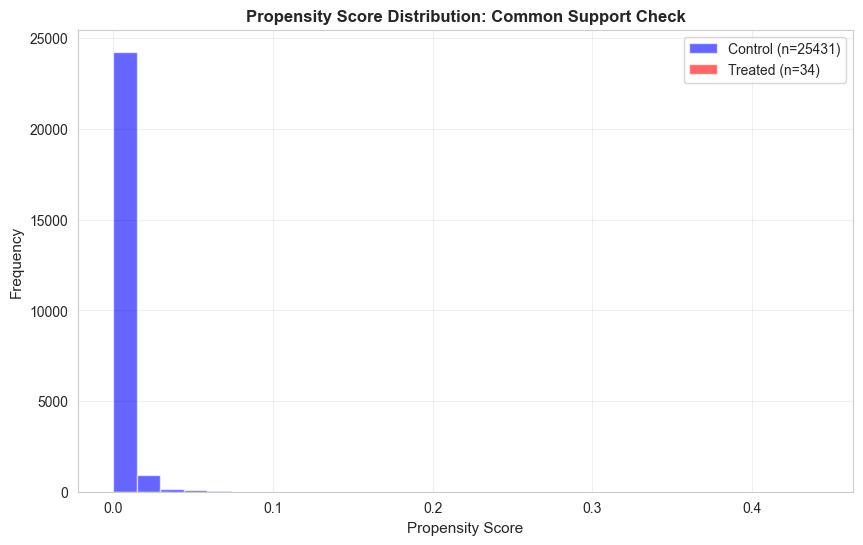

In [4]:
# Check common support assumption
support_report = analysis.check_common_support(
    df,
    ps_col='propensity_score',
    treatment_col='green_bond_active'
)

print('\nCommon Support Verification:')
print(f'  Treated units with support: {support_report["treated_overlap_pct"]:.1f}%')
print(f'  Control units with support: {support_report["control_overlap_pct"]:.1f}%')
print(f'  Support range: [{support_report["overlap_region"][0]:.4f}, {support_report["overlap_region"][1]:.4f}]')

# Visualize
fig = utils.plot_propensity_score_overlap(
    df,
    save_path='images/01_propensity_scores.png'
)
print('\n✅ Saved: 01_propensity_scores.png')

In [5]:
# Run DiD for multiple outcomes
print('\n' + '='*60)
print('DIFFERENCE-IN-DIFFERENCES ESTIMATION')
print('='*60)

outcomes = ['return_on_assets', 'return_on_equity_total', 'esg_score']
specs = ['entity_fe', 'time_fe', 'twoway_fe', 'none']

results = analysis.run_multiple_outcomes(
    df,
    outcomes=outcomes,
    treatment_col='green_bond_active',
    specifications=specs
)

print(f'\nEstimated {len(results)} models')
print('\nResults Summary:')
print(results[['outcome', 'specification', 'coefficient', 'std_error', 'p_value']].head(12))


DIFFERENCE-IN-DIFFERENCES ESTIMATION

Estimated 12 models

Results Summary:
                   outcome specification  coefficient  std_error       p_value
0         return_on_assets     entity_fe    -0.009966   0.004687  3.348815e-02
1         return_on_assets       time_fe     0.012164   0.007182  9.033388e-02
2         return_on_assets     twoway_fe    -0.007120   0.005263  1.761182e-01
3         return_on_assets          none     0.013672   0.006996  5.068111e-02
4   return_on_equity_total     entity_fe    -0.017094   0.014374  2.343646e-01
5   return_on_equity_total       time_fe     0.072337   0.012535  7.975887e-09
6   return_on_equity_total     twoway_fe    -0.008550   0.015779  5.879120e-01
7   return_on_equity_total          none     0.077656   0.012277  2.561973e-10
8                esg_score     entity_fe     6.260823   1.755906  3.671604e-04
9                esg_score       time_fe    12.985407   2.406703  7.142969e-08
10               esg_score     twoway_fe     0.757960 


Parallel Trends Testing (Leads/Lags)...

Leads and Lags of Treatment:
  treatment_lead_1              :   0.0018     (p=0.6213)
  treatment_lead_2              :   0.0023     (p=0.5961)
  treatment_lead_3              :  -0.0055 *   (p=0.0747)
  green_bond_active             :  -0.0241 *** (p=0.0024)
  treatment_lag_1               :   0.0058     (p=0.4130)
  treatment_lag_2               :   0.0164     (p=0.2211)
  treatment_lag_3               :  -0.0187 *   (p=0.0525)

✅ Saved: 02_parallel_trends.png


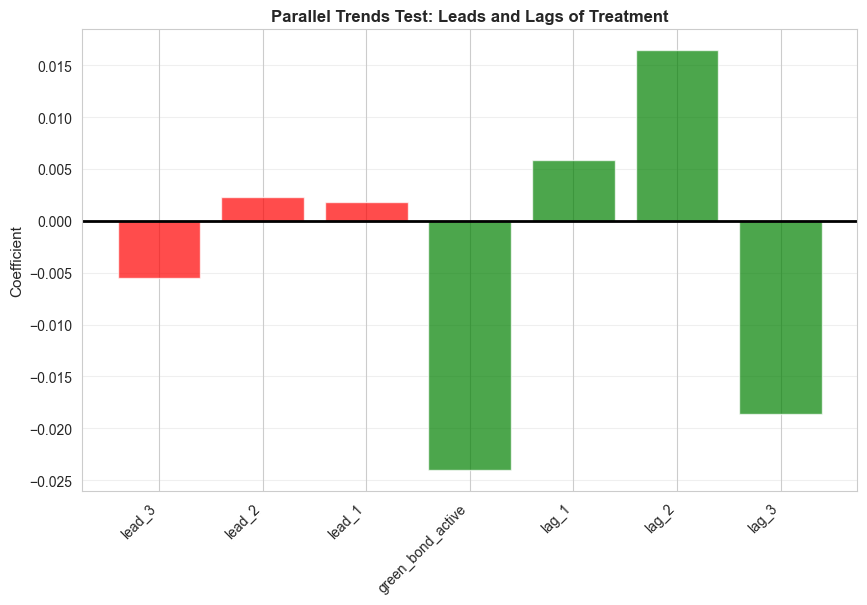

In [6]:
# Test parallel trends assumption
print('\nParallel Trends Testing (Leads/Lags)...')

pt_results = analysis.parallel_trends_test(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active',
    leads=3,
    lags=3
)

print('\nLeads and Lags of Treatment:')
for col, coef in pt_results['coefficients'].items():
    pval = pt_results['p_values'][col]
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
    print(f'  {col:30s}: {coef:8.4f} {sig:3s} (p={pval:.4f})')

# Visualize
fig = utils.plot_parallel_trends(pt_results, save_path='images/02_parallel_trends.png')
print('\n✅ Saved: 02_parallel_trends.png')

In [7]:
# Run specification sensitivity
print('\n' + '='*60)
print('ROBUSTNESS CHECKS')
print('='*60)

sensitivity = analysis.specification_sensitivity(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active'
)

print('\nSpecification Sensitivity:')
print(sensitivity[['specification', 'n_controls', 'coefficient', 'std_error', 'p_value']].to_string())

# Placebo test
placebo = analysis.placebo_test(
    df,
    outcome='return_on_assets',
    treatment_col='green_bond_active'
)

print(f'\nPlacebo Test (shifted treatment):')  
print(f'  Placebo effect: {placebo.get("placebo_coefficient", np.nan):.4f}')
print(f'  p-value: {placebo.get("placebo_p_value", np.nan):.4f}')
print(f'  ✓ Valid' if placebo.get('is_zero_at_5pct') else '  ✗ Concern')


ROBUSTNESS CHECKS

Specification Sensitivity:
  specification  n_controls  coefficient  std_error   p_value
0        Spec_1           0    -0.019847   0.004464  0.000009
1        Spec_2           1    -0.009641   0.004750  0.042407
2        Spec_3           2    -0.009601   0.004735  0.042617
3        Spec_4           3    -0.011214   0.004655  0.015996
4        Spec_5           4    -0.009966   0.004687  0.033488

Placebo Test (shifted treatment):
  Placebo effect: -0.0166
  p-value: 0.0015
  ✗ Concern


In [8]:
# Run full diagnostics
print('\nRunning comprehensive diagnostic tests...')

diagnostics = analysis.run_diagnostics_battery(
    df,
    outcome='return_on_assets'
)

print('\n✅ Diagnostics Complete')
print(f'  Placebo: {diagnostics["placebo"].get("is_zero_at_5pct", "N/A")}')
print(f'  LOOCV robustness: {diagnostics["loocv"].get("robust", "N/A")}')
print(f'  Specifications tested: {len(diagnostics["spec_sensitivity"])}')


Running comprehensive diagnostic tests...
Running placebo test...
Running specification sensitivity...
Running leave-one-out CV...
Analyzing heterogeneous effects...

✅ Diagnostics Complete
  Placebo: False
  LOOCV robustness: True
  Specifications tested: 5


In [9]:
print('\n' + '='*60)
print('ANALYSIS COMPLETE')
print('='*60)
print('\n✅ Outputs saved to images/')
print('\nKey results:')
print(f'  - {len(results)} DiD estimates (outcomes × specifications)')
print(f'  - Parallel trends tested (leads/lags)') 
print(f'  - Robustness checks completed')
print(f'  - Visualizations created')
print('\nNext: Review results and visualizations in images/')


ANALYSIS COMPLETE

✅ Outputs saved to images/

Key results:
  - 12 DiD estimates (outcomes × specifications)
  - Parallel trends tested (leads/lags)
  - Robustness checks completed
  - Visualizations created

Next: Review results and visualizations in images/
